# Netflix Content Analysis Using Python

**Goal:** Explore Netflix's catalog, clean the raw data, identify content patterns, and communicate useful insights through visualizations.

**Dataset:** `8,807` titles with `12` original fields.

## Questions
1. What is the balance between movies and TV shows?
2. Which countries contribute the most titles?
3. How has content acquisition changed over time?
4. Which ratings and genres dominate the catalog?
5. How long are Netflix movies, and how many seasons do TV shows typically have?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 15, "axes.labelsize": 11})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "netflix_titles.csv"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Data audit

In [2]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.info()

Rows: 8,807 | Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing", ascending=False)
audit

,dtype,missing,missing_pct,unique_values
director,object,2634,29.91,4528
country,object,831,9.44,748
cast,object,825,9.37,7692
date_added,object,10,0.11,1767
rating,object,4,0.05,17
duration,object,3,0.03,220
show_id,object,0,0.00,8807
type,object,0,0.00,2
title,object,0,0.00,8807
release_year,int64,0,0.00,74


### Audit findings

The columns with the most missing data are `director`, `cast`, and `country`. These are descriptive fields, so replacing missing values with **Unknown** preserves rows without fabricating information. Dates and duration values require type conversion before analysis.

## 2. Data cleaning and feature engineering

In [4]:
clean = df.drop_duplicates().copy()
clean["date_added"] = pd.to_datetime(clean["date_added"].str.strip(), errors="coerce")
for column in ["director", "cast", "country", "rating", "duration"]:
    clean[column] = clean[column].fillna("Unknown")

clean["year_added"] = clean["date_added"].dt.year.astype("Int64")
clean["month_added"] = clean["date_added"].dt.month_name()
clean["primary_country"] = clean["country"].str.split(",").str[0].str.strip()
clean["primary_genre"] = clean["listed_in"].str.split(",").str[0].str.strip()
duration_number = pd.to_numeric(clean["duration"].str.extract(r"(\d+)")[0], errors="coerce")
clean["movie_minutes"] = duration_number.where(clean["type"].eq("Movie"))
clean["seasons"] = duration_number.where(clean["type"].eq("TV Show"))

print(f"Duplicate rows removed: {len(df) - len(clean)}")
clean.head()

Duplicate rows removed: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,primary_country,primary_genre,movie_minutes,seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,United States,Documentaries,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,South Africa,International TV Shows,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,Unknown,Crime TV Shows,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,Unknown,Docuseries,NaN,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,India,International TV Shows,NaN,2.0


In [5]:
clean.to_csv(PROJECT_ROOT / "data" / "netflix_titles_cleaned.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


## 3. Movies versus TV shows

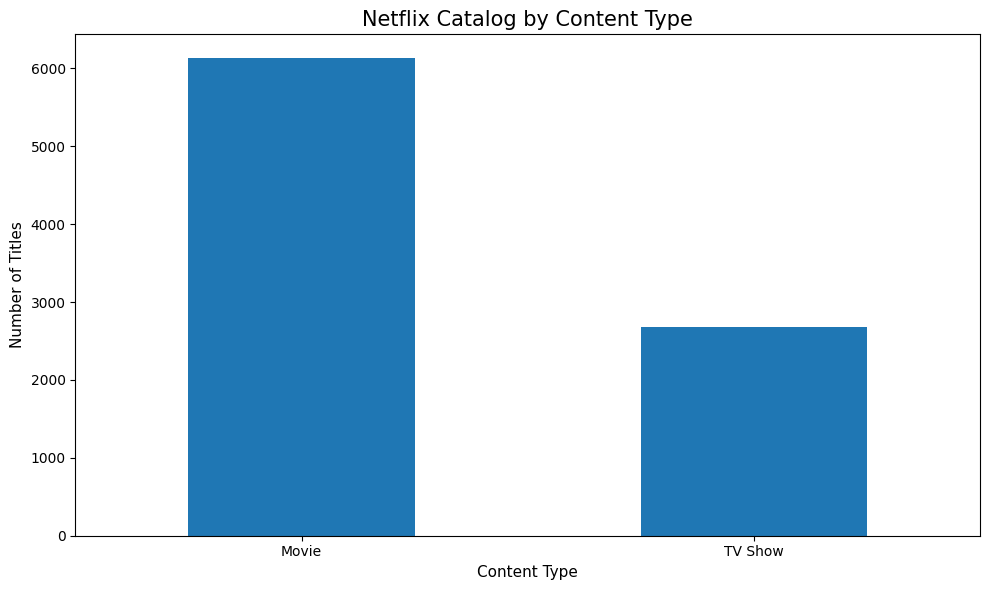

type
Movie      69.6
TV Show    30.4
Name: percentage, dtype: float64

In [6]:
type_counts = clean["type"].value_counts()
ax = type_counts.plot(kind="bar", title="Netflix Catalog by Content Type")
ax.set(xlabel="Content Type", ylabel="Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "content_type.png", dpi=180, bbox_inches="tight")
plt.show()
(type_counts / len(clean) * 100).round(1).rename("percentage")

**Finding:** Movies represent about **69.6%** of the catalog, while TV shows account for **30.4%**.

## 4. Countries contributing the most content

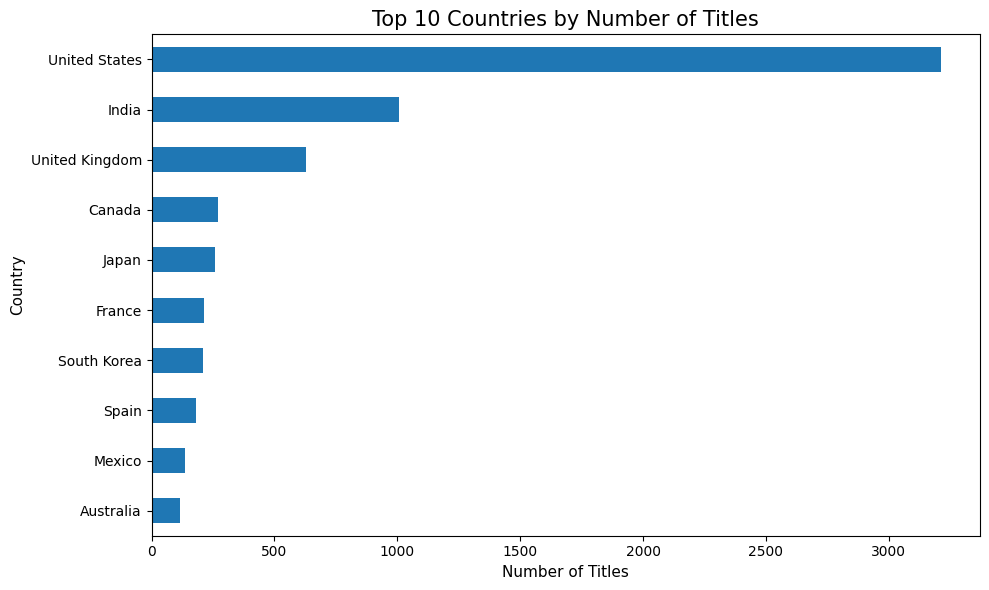

primary_country
United States     3211
India             1008
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Australia          117
Name: count, dtype: int64

In [7]:
top_countries = (clean.loc[clean["primary_country"] != "Unknown", "primary_country"]
                 .value_counts().head(10))
ax = top_countries.sort_values().plot(kind="barh", title="Top 10 Countries by Number of Titles")
ax.set(xlabel="Number of Titles", ylabel="Country")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "top_countries.png", dpi=180, bbox_inches="tight")
plt.show()
top_countries

**Finding:** **United States** is the largest single-country contributor in the dataset.

## 5. When titles were added

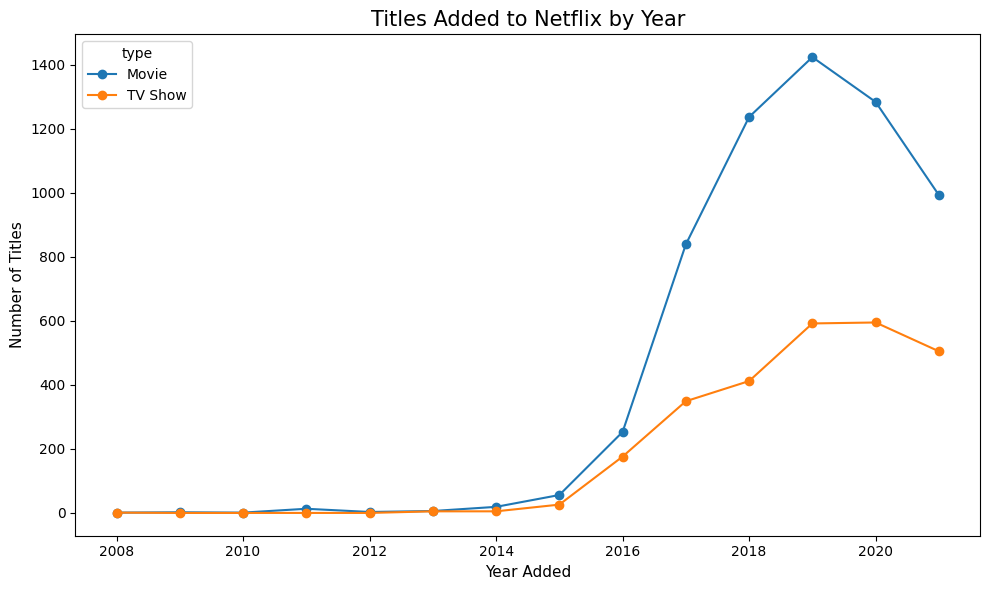

type,Movie,TV Show
year_added,,
2017,839,349
2018,1237,412
2019,1424,592
2020,1284,595
2021,993,505


In [8]:
added_by_year = clean.dropna(subset=["year_added"]).groupby(["year_added", "type"]).size().unstack(fill_value=0)
ax = added_by_year.plot(marker="o", title="Titles Added to Netflix by Year")
ax.set(xlabel="Year Added", ylabel="Number of Titles")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "titles_added_by_year.png", dpi=180, bbox_inches="tight")
plt.show()
added_by_year.tail()

**Finding:** The dataset records the highest number of additions in **2019**, indicating a major catalog expansion period.

## 6. Ratings and audience positioning

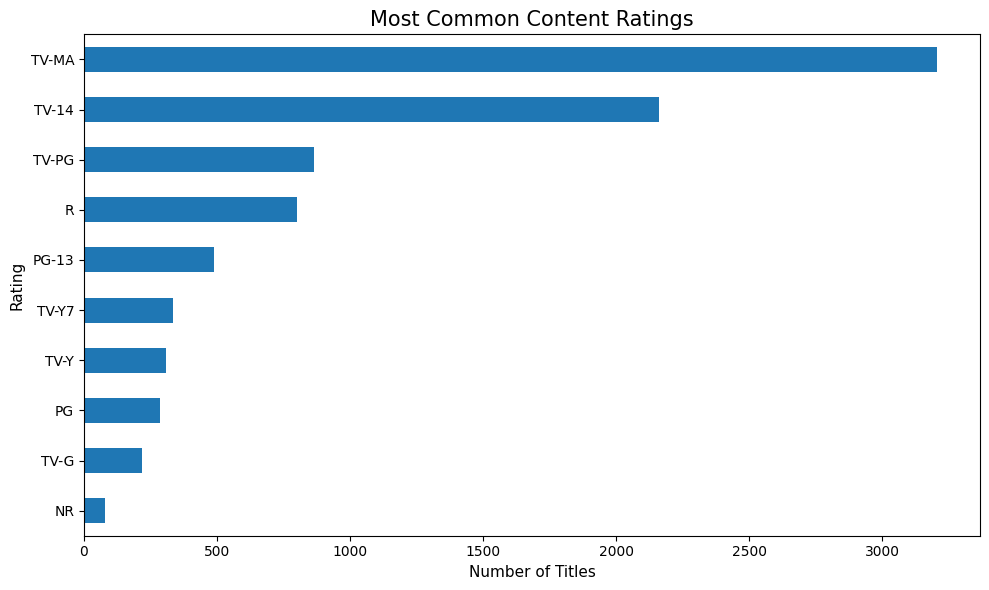

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [9]:
rating_counts = clean.loc[clean["rating"] != "Unknown", "rating"].value_counts().head(10)
ax = rating_counts.sort_values().plot(kind="barh", title="Most Common Content Ratings")
ax.set(xlabel="Number of Titles", ylabel="Rating")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "ratings.png", dpi=180, bbox_inches="tight")
plt.show()
rating_counts

**Finding:** **TV-MA** is the most frequent rating, suggesting a strong emphasis on mature or older-teen audiences.

## 7. Most common genres

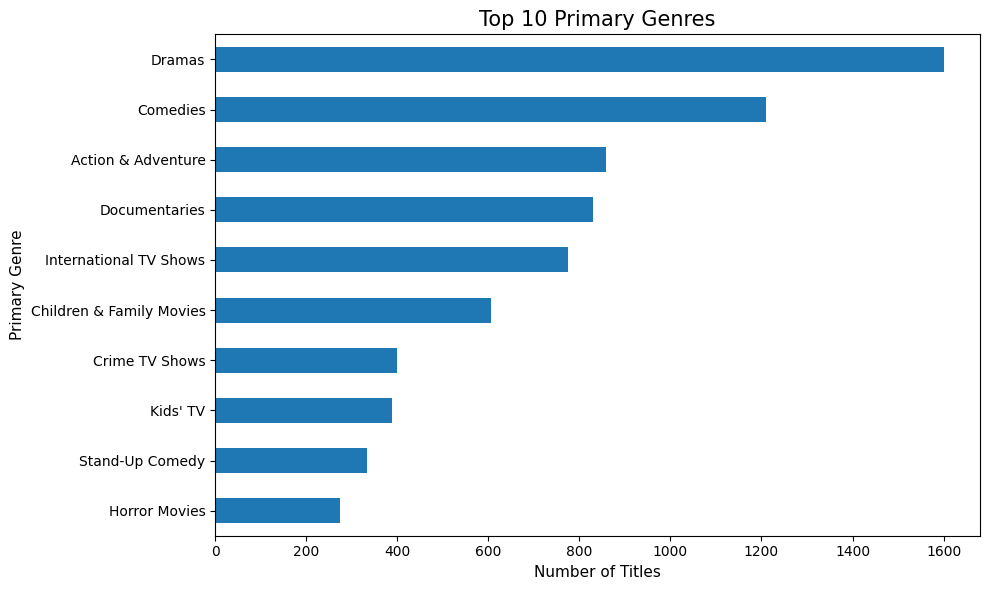

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

In [10]:
genre_counts = clean["primary_genre"].value_counts().head(10)
ax = genre_counts.sort_values().plot(kind="barh", title="Top 10 Primary Genres")
ax.set(xlabel="Number of Titles", ylabel="Primary Genre")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "genres.png", dpi=180, bbox_inches="tight")
plt.show()
genre_counts

**Finding:** **Dramas** is the most common primary genre in this catalog.

## 8. Movie duration and TV-show seasons

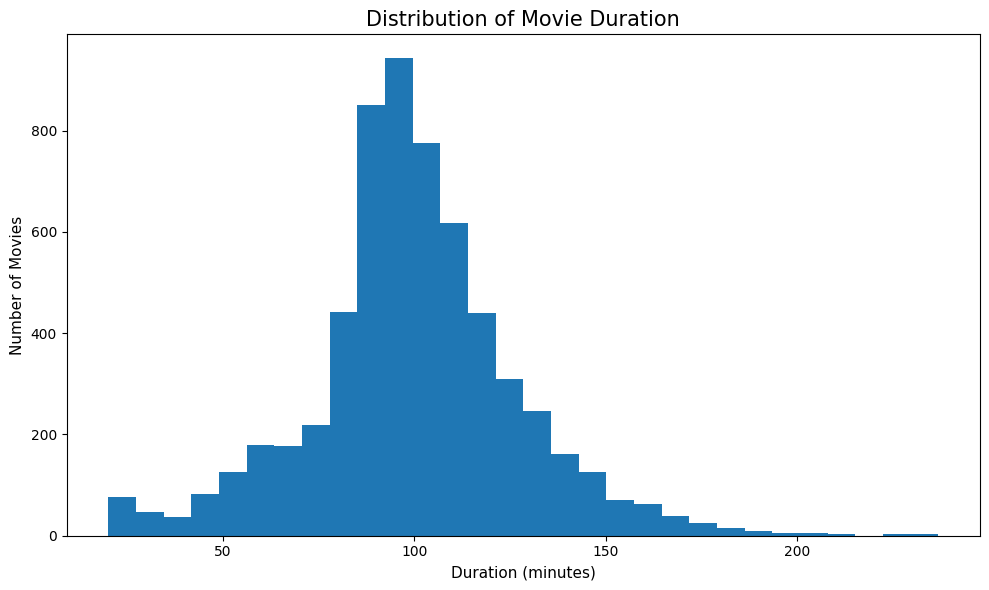

count    6099.0
mean       99.9
std        27.5
min        20.0
25%        87.0
50%        98.0
75%       114.5
max       237.0
Name: movie_minutes, dtype: float64

In [11]:
movie_duration = clean.loc[clean["movie_minutes"].between(20, 240), "movie_minutes"]
ax = movie_duration.plot(kind="hist", bins=30, title="Distribution of Movie Duration")
ax.set(xlabel="Duration (minutes)", ylabel="Number of Movies")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "movie_duration.png", dpi=180, bbox_inches="tight")
plt.show()
movie_duration.describe().round(1)

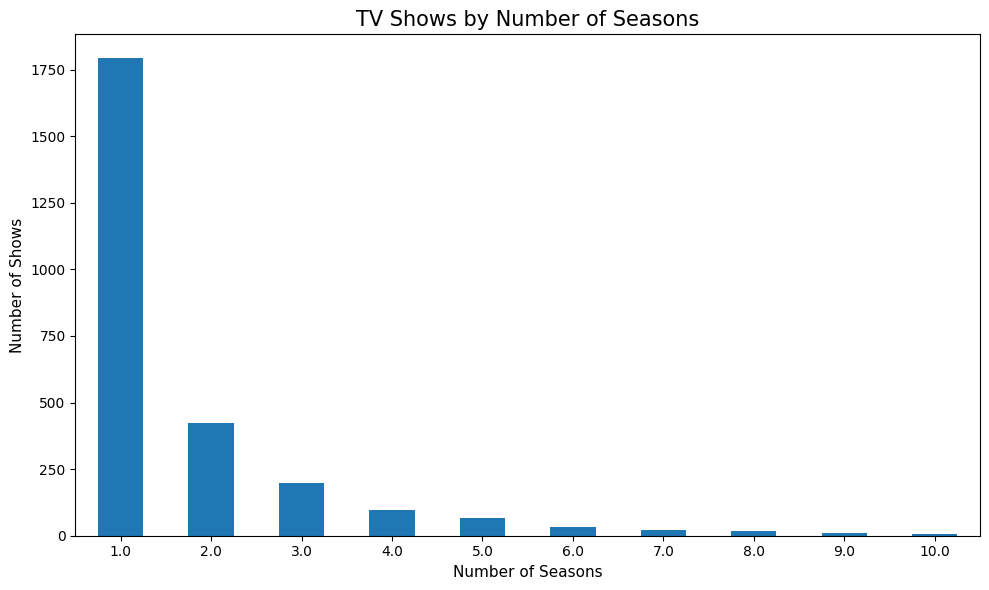

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
Name: count, dtype: int64

In [12]:
season_counts = clean.loc[clean["type"].eq("TV Show"), "seasons"].value_counts().sort_index().head(10)
ax = season_counts.plot(kind="bar", title="TV Shows by Number of Seasons")
ax.set(xlabel="Number of Seasons", ylabel="Number of Shows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
season_counts

**Finding:** The median movie runtime is approximately **98 minutes**, while most TV shows have relatively few seasons.

## 9. Country and content-type mix

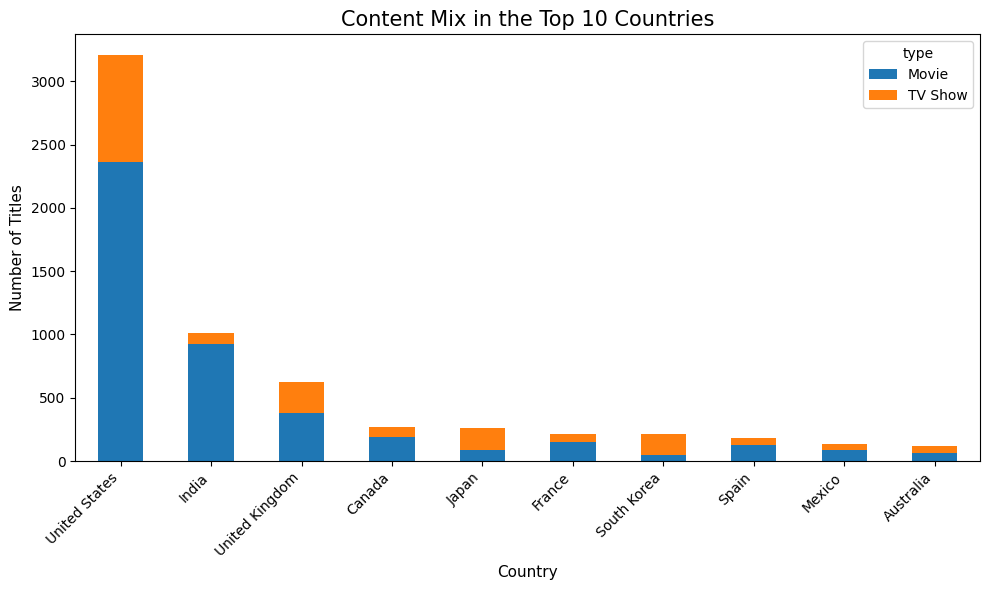

type,Movie,TV Show
primary_country,,
United States,2364,847
India,927,81
United Kingdom,382,246
Canada,187,84
Japan,85,174
France,148,64
South Korea,47,164
Spain,129,52
Mexico,86,48


In [13]:
mix = pd.crosstab(
    clean.loc[clean["primary_country"] != "Unknown", "primary_country"],
    clean.loc[clean["primary_country"] != "Unknown", "type"]
)
mix["Total"] = mix.sum(axis=1)
top_mix = mix.nlargest(10, "Total").drop(columns="Total")
ax = top_mix.plot(kind="bar", stacked=True, title="Content Mix in the Top 10 Countries")
ax.set(xlabel="Country", ylabel="Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "country_content_mix.png", dpi=180, bbox_inches="tight")
plt.show()
top_mix

## 10. Conclusion

The analysis shows that Netflix's catalog is movie-heavy, internationally diverse, and concentrated in a small number of major content-producing countries. Additions accelerated sharply during the platform's expansion years, while mature-audience ratings and drama-oriented genres occupy prominent positions.

### Portfolio takeaways
- Cleaned inconsistent dates, missing descriptive values, and mixed duration formats.
- Engineered reusable features for year, month, country, genre, runtime, and seasons.
- Used grouped analysis and visual storytelling to explain catalog composition.
- Exported a cleaned dataset and publication-ready charts for reuse.

### Possible extensions
- Analyze actor and director networks.
- Build an interactive Plotly or Streamlit dashboard.
- Use NLP to cluster title descriptions.
- Compare Netflix's catalog with another streaming platform.